In [2]:
import os
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('..')
from utils.analysis import est_vifs

In [3]:
PPI_DIR = ('/mnt/data/learning-habits/spm_format/outputs/PPI/'
           'gppi_putamen_Hvalchosen_deconv_2026-03-18-07-39-25')
SEED_NAME = 'putamen'

In [4]:
def load_dms_ppi(ppi_dir, seed_name='putamen'):
    """Load design matrices from ppi_dir/sub-XX/PPI_<seed>/sub-XX_design_matrix.csv."""
    subjects = sorted(d for d in os.listdir(ppi_dir) if d.startswith('sub-'))
    DMs = {}
    for sub in subjects:
        ppi_subdir = os.path.join(ppi_dir, sub, f'PPI_{seed_name}')
        dm_path  = os.path.join(ppi_subdir, f'{sub}_design_matrix.csv')
        col_path = os.path.join(ppi_subdir, f'{sub}_column_names.txt')
        if not (os.path.exists(dm_path) and os.path.exists(col_path)):
            continue
        with open(col_path) as f:
            col_names = [l.strip() for l in f]
        DMs[sub] = pd.read_csv(dm_path, names=col_names, header=None)
    return DMs


def compute_vifs_ppi(DMs, n_sessions=3):
    """
    Compute VIFs for task + PPI regressors per subject and session.
    Excludes: R\d+ confounds, 'constant', and constant-valued columns.
    Returns a DataFrame indexed by (subject, session).
    """
    records = []
    for sub, dm in DMs.items():
        for sn in range(1, n_sessions + 1):
            prefix = f'Sn({sn}) '
            sess_cols = [c for c in dm.columns if c.startswith(prefix)]
            if not sess_cols:
                continue
            dm_sess = dm[sess_cols]

            task_cols = [
                c for c in sess_cols
                if not re.search(r'\bR\d+$', c)
                and 'constant' not in c.lower()
                and dm_sess[c].nunique() > 1
            ]
            if not task_cols:
                continue

            try:
                vifs = est_vifs(dm_sess, task_cols)
            except Exception as e:
                print(f'  Warning: VIF failed for {sub} Sn({sn}): {e}')
                continue

            vifs_clean = {k.replace(prefix, ''): v for k, v in vifs.items()}
            vifs_clean['subject'] = sub
            vifs_clean['session'] = f'Sn({sn})'
            records.append(vifs_clean)

    df = pd.DataFrame(records).set_index(['subject', 'session'])
    return df


def shorten(name):
    name = re.sub(r'\*bf\(\d+\)', '', name)
    name = re.sub(r'\^\d+', '', name)
    name = name.replace('first_stim', '1st').replace('second_stim', '2nd')
    name = name.replace('_chosen', '')
    return name

In [5]:
DMs = load_dms_ppi(PPI_DIR, SEED_NAME)
print(f'Loaded {len(DMs)} subjects')

VIFs = compute_vifs_ppi(DMs)
print(f'VIF table: {VIFs.shape[0]} rows × {VIFs.shape[1]} regressors')
print('\nColumn groups:')
print('  Task:  ', [c for c in VIFs.columns if 'PPI' not in c and SEED_NAME not in c])
print('  PPI:   ', [c for c in VIFs.columns if 'PPI_' in c])
print('  Seed:  ', [c for c in VIFs.columns if SEED_NAME in c and 'PPI' not in c])

Loaded 60 subjects
VIF table: 180 rows × 17 regressors

Column groups:
  Task:   ['first_stim*bf(1)', 'second_stim*bf(1)', 'second_stimxQval_chosen^1*bf(1)', 'second_stimxHval_chosen^1*bf(1)', 'response*bf(1)', 'purple_frame*bf(1)', 'points_feedback*bf(1)', 'nresp_screen*bf(1)', 'second_stim_nresp*bf(1)']
  PPI:    ['PPI_first_stim', 'PPI_second_stim', 'PPI_second_stimxQval_chosen^1', 'PPI_second_stimxHval_chosen^1', 'PPI_response', 'PPI_purple_frame', 'PPI_points_feedback']
  Seed:   ['putamen_seedtc']


## VIF summary

In [6]:
display(VIFs.describe().round(2))

,first_stim*bf(1),second_stim*bf(1),second_stimxQval_chosen^1*bf(1),second_stimxHval_chosen^1*bf(1),response*bf(1),purple_frame*bf(1),points_feedback*bf(1),nresp_screen*bf(1),second_stim_nresp*bf(1),PPI_first_stim,PPI_second_stim,PPI_second_stimxQval_chosen^1,PPI_second_stimxHval_chosen^1,PPI_response,PPI_purple_frame,PPI_points_feedback,putamen_seedtc
count,180.00,180.00,180.00,180.00,180.00,180.00,120.00,125.00,125.00,180.00,180.00,180.00,180.00,180.00,180.00,120.00,180.00
mean,50.27,33.63,1.96,8.67,1190.10,1267.71,75.77,10.52,12.03,8.88,38.69,2.05,7.83,228.96,189.35,13.07,1.66
std,29.19,13.31,0.56,9.03,899.22,932.85,9.84,22.68,4.88,3.39,13.71,0.68,8.04,163.17,146.61,2.90,0.30
min,8.82,13.30,1.20,1.37,15.08,10.50,52.12,5.80,6.09,3.63,17.11,1.18,1.21,11.30,1.82,7.70,1.21
25%,12.02,23.89,1.55,2.31,24.56,57.07,68.71,7.20,8.73,5.89,28.77,1.61,2.22,23.28,2.39,10.94,1.42
50%,63.11,31.15,1.83,3.15,1529.02,1626.20,74.32,7.98,10.50,8.98,35.45,1.90,3.63,276.03,232.79,12.92,1.55
75%,71.89,42.79,2.24,16.30,1791.33,1904.29,82.79,9.37,14.43,11.02,47.28,2.29,12.95,357.44,294.24,14.69,1.88
max,112.54,97.56,4.32,36.67,4453.78,4626.91,109.26,261.30,38.57,20.56,80.78,4.75,43.05,684.80,616.50,25.47,2.52


In [7]:
print('Max VIF per session:')
display(VIFs.groupby('session').max().round(1))

Max VIF per session:


,first_stim*bf(1),second_stim*bf(1),second_stimxQval_chosen^1*bf(1),second_stimxHval_chosen^1*bf(1),response*bf(1),purple_frame*bf(1),points_feedback*bf(1),nresp_screen*bf(1),second_stim_nresp*bf(1),PPI_first_stim,PPI_second_stim,PPI_second_stimxQval_chosen^1,PPI_second_stimxHval_chosen^1,PPI_response,PPI_purple_frame,PPI_points_feedback,putamen_seedtc
session,,,,,,,,,,,,,,,,,
Sn(1),91.8,97.6,3.3,36.7,4453.8,4626.9,88.2,12.7,25.4,16.4,80.8,4.8,43.0,684.8,616.5,21.6,1.8
Sn(2),112.5,50.2,3.8,4.1,4040.0,4010.4,109.3,16.2,22.5,20.6,70.6,3.6,4.2,543.3,486.6,25.5,1.9
Sn(3),16.6,43.0,4.3,6.8,35.3,222.5,NaN,261.3,38.6,8.0,48.1,4.6,7.6,33.2,3.1,NaN,2.5


## Boxplots: pmod regressors

In [13]:
VIFs.columns

Index(['first_stim*bf(1)', 'second_stim*bf(1)',
       'second_stimxQval_chosen^1*bf(1)', 'second_stimxHval_chosen^1*bf(1)',
       'response*bf(1)', 'purple_frame*bf(1)', 'points_feedback*bf(1)',
       'nresp_screen*bf(1)', 'second_stim_nresp*bf(1)', 'PPI_first_stim',
       'PPI_second_stim', 'PPI_second_stimxQval_chosen^1',
       'PPI_second_stimxHval_chosen^1', 'PPI_response', 'PPI_purple_frame',
       'PPI_points_feedback', 'putamen_seedtc'],
      dtype='object')

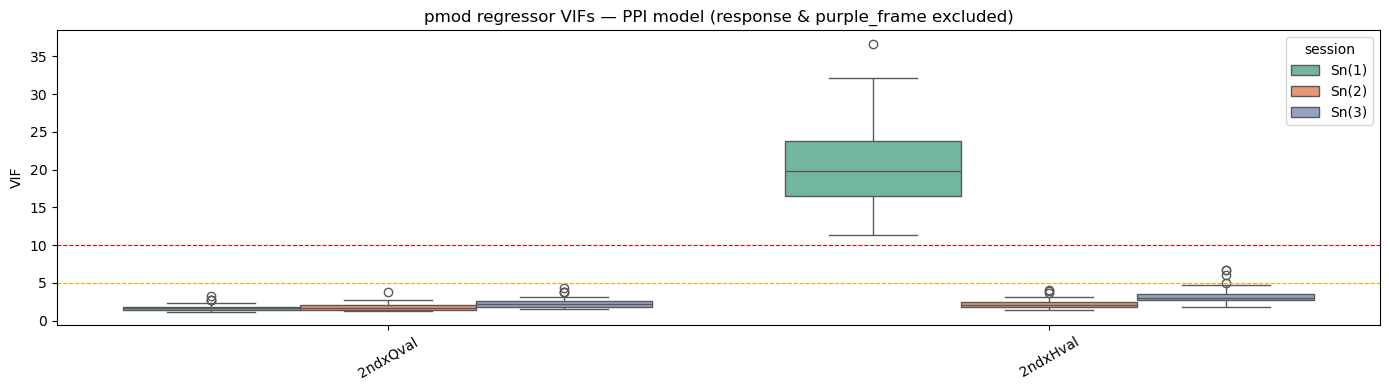

In [16]:
# hand picking which task regressors to plot (excluding PPI, seed, response, and purple_frame)
pmod_cols = [
     'second_stimxQval_chosen^1*bf(1)', 'second_stimxHval_chosen^1*bf(1)',
]

melted = (
    VIFs[pmod_cols].reset_index()
    .melt(id_vars=['subject', 'session'], var_name='regressor', value_name='VIF')
)
melted['regressor'] = melted['regressor'].map(shorten)

fig, ax = plt.subplots(figsize=(14, 4))
sns.boxplot(data=melted, x='regressor', y='VIF', hue='session', palette='Set2', ax=ax)
ax.axhline(5,  color='orange', linestyle='--', linewidth=0.8)
ax.axhline(10, color='red',    linestyle='--', linewidth=0.8)
ax.set_title('pmod regressor VIFs — PPI model (response & purple_frame excluded)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## Boxplots: PPI interaction regressors + seed timeseries

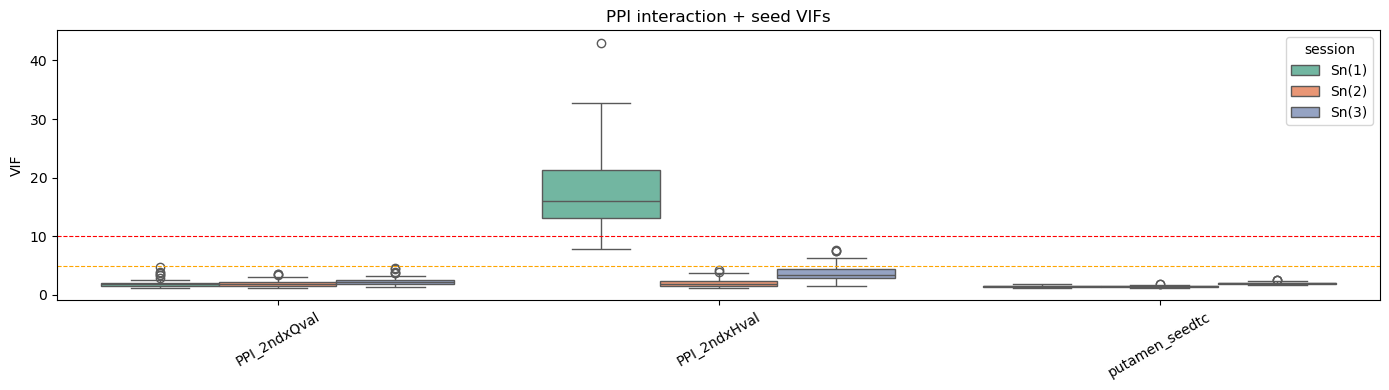

In [17]:
ppi_cols = ['PPI_second_stimxQval_chosen^1',
       'PPI_second_stimxHval_chosen^1', 'putamen_seedtc']

melted_ppi = (
    VIFs[ppi_cols].reset_index()
    .melt(id_vars=['subject', 'session'], var_name='regressor', value_name='VIF')
)
melted_ppi['regressor'] = melted_ppi['regressor'].map(shorten)

fig, ax = plt.subplots(figsize=(14, 4))
sns.boxplot(data=melted_ppi, x='regressor', y='VIF', hue='session', palette='Set2', ax=ax)
ax.axhline(5,  color='orange', linestyle='--', linewidth=0.8)
ax.axhline(10, color='red',    linestyle='--', linewidth=0.8)
ax.set_title('PPI interaction + seed VIFs')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## Focus: Hval pmod and PPI_Hval regressors

The key regressors of interest for this PPI analysis.

Hval columns: ['second_stimxHval_chosen^1*bf(1)', 'PPI_second_stimxHval_chosen^1']


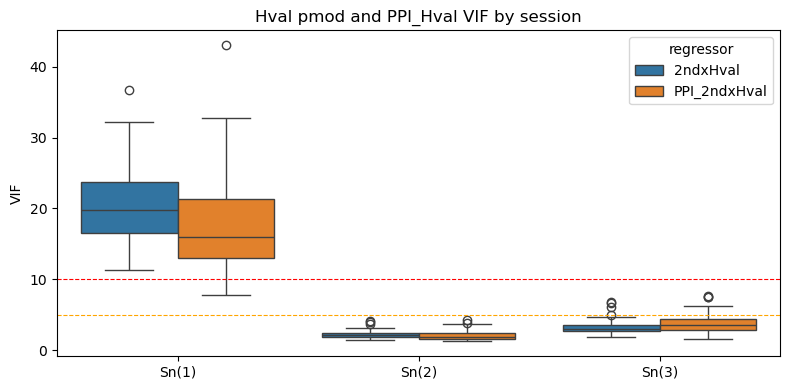


Hval VIFs — max per session:


,second_stimxHval_chosen^1*bf(1),PPI_second_stimxHval_chosen^1
session,,
Sn(1),36.67,43.05
Sn(2),4.12,4.24
Sn(3),6.78,7.58


In [10]:
hval_cols = [c for c in VIFs.columns if 'Hval' in c]
print('Hval columns:', hval_cols)

melted_hval = (
    VIFs[hval_cols].reset_index()
    .melt(id_vars=['subject', 'session'], var_name='regressor', value_name='VIF')
)
melted_hval['regressor'] = melted_hval['regressor'].map(shorten)

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=melted_hval, x='session', y='VIF', hue='regressor', palette='tab10', ax=ax)
ax.axhline(5,  color='orange', linestyle='--', linewidth=0.8)
ax.axhline(10, color='red',    linestyle='--', linewidth=0.8)
ax.set_title('Hval pmod and PPI_Hval VIF by session')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

print('\nHval VIFs — max per session:')
display(VIFs[hval_cols].groupby('session').max().round(2))

## Why is PPI_Hval VIF high if it's not correlated with its base task regressor?

VIF is not a pairwise measure — it is the R² from regressing each column against *all other columns*. `PPI_second_stimxHval_chosen` can be nearly uncorrelated with its base task counterpart `second_stimxHval_chosen*bf(1)` while still being strongly collinear with another PPI term.

The culprit is `PPI_second_stim`. In Sn(1), subjects are early in learning and the choice kernel H-values have barely diverged across stimuli, so Hval is nearly flat within the session. A near-constant parametric modulator is approximately proportional to the main condition regressor: `second_stimxHval ≈ k × second_stim`. When the gPPI interaction is formed by multiplying the seed timeseries by that psychological variable, the same proportionality carries over: `PPI_second_stimxHval ≈ k × PPI_second_stim`.

Correlating `PPI_second_stimxHval_chosen` against every other PPI regressor confirms this:

| Session | r(PPI_Hval, PPI_second_stim) |
|---------|------------------------------|
| Sn(1)   | **−0.95** (mean across subjects) |
| Sn(2)   | −0.10 |
| Sn(3)   | +0.62 |

The negative sign arises because SPM orthogonalises the parametric modulator against its main condition before model estimation, effectively flipping the pmod relative to the raw Hval × condition relationship. But the sign is irrelevant for VIF, which depends only on |r|.

**Root cause:** the Sn(1) Hval behavioural collinearity that inflates VIFs in the base GLM is directly inherited by the PPI interaction terms. Sessions 2 and 3 have more Hval variance and are therefore much less collinear.

## Correlation: PPI interaction regressors vs their base task counterparts

High correlation between `PPI_<cond>` and `<cond>*bf(1)` indicates the PPI term is nearly collinear with the task regressor.

=== r(PPI_<cond>, <cond>*bf(1)) — mean (std) across subjects ===


mean    std
regressor       session              
1st             Sn(1)    0.060  0.072
                Sn(2)    0.095  0.061
                Sn(3)    0.108  0.068
2nd             Sn(1)    0.008  0.107
                Sn(2)    0.068  0.094
                Sn(3)    0.074  0.093
2ndxHval        Sn(1)   -0.024  0.137
                Sn(2)    0.192  0.254
                Sn(3)    0.216  0.167
2ndxQval        Sn(1)    0.058  0.263
                Sn(2)    0.220  0.230
                Sn(3)    0.226  0.239
points_feedback Sn(1)   -0.031  0.093
                Sn(2)   -0.005  0.076
purple_frame    Sn(1)   -0.001  0.091
                Sn(2)    0.050  0.078
                Sn(3)   -0.002  0.007
response        Sn(1)    0.014  0.088
                Sn(2)    0.067  0.077
                Sn(3)    0.075  0.080

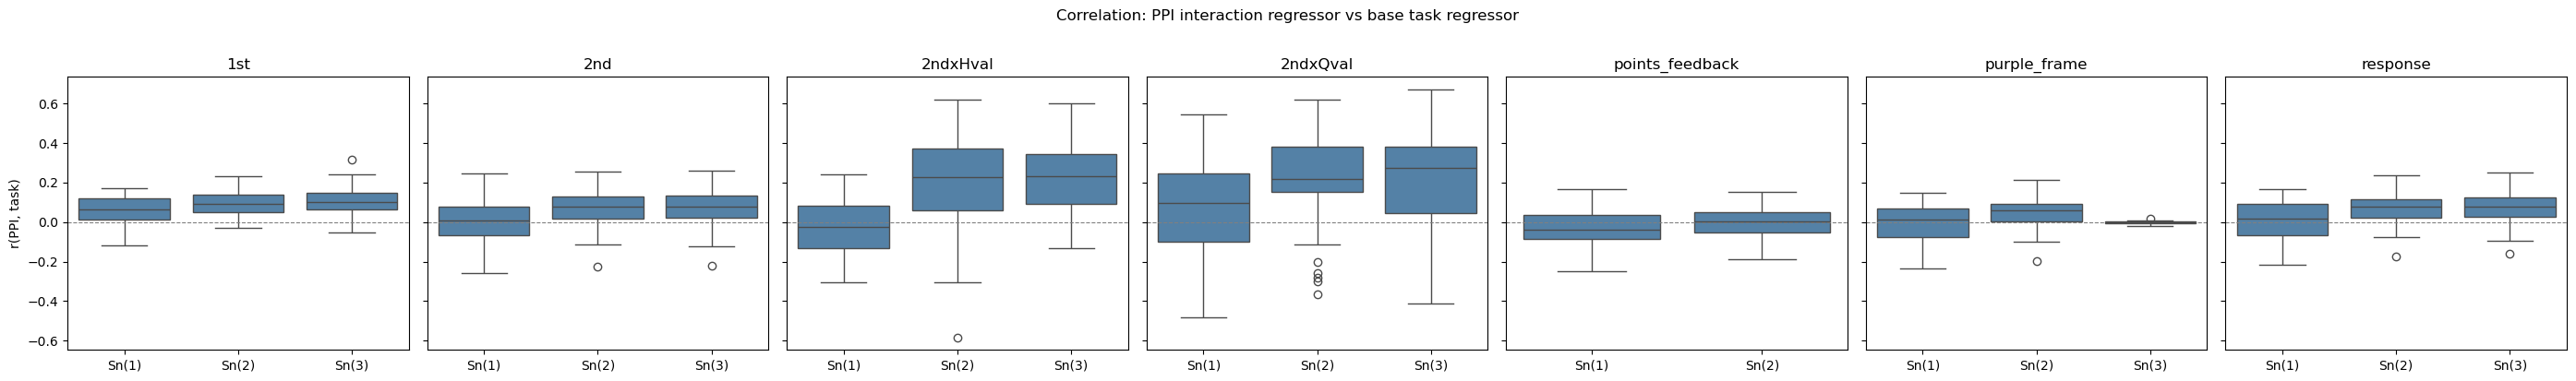

In [11]:
def compute_ppi_task_corr(DMs, seed_name, n_sessions=3):
    """
    For each PPI interaction regressor, correlate with its matching base task regressor.
    PPI_<cond> is matched to <cond>*bf(1).
    """
    records = []
    for sub, dm in DMs.items():
        for sn in range(1, n_sessions + 1):
            prefix = f'Sn({sn}) '
            ppi_cols = [
                c for c in dm.columns
                if c.startswith(prefix + 'PPI_') and seed_name not in c
            ]
            for pc in ppi_cols:
                cond = pc.replace(prefix + 'PPI_', '')
                # find matching base task col (with *bf(1) suffix)
                base_col = f'{prefix}{cond}*bf(1)'
                if base_col not in dm.columns:
                    continue
                r = dm[pc].corr(dm[base_col])
                records.append({
                    'subject': sub,
                    'session': f'Sn({sn})',
                    'regressor': shorten(cond),
                    'r': r,
                })
    return pd.DataFrame(records)


corr_df = compute_ppi_task_corr(DMs, SEED_NAME)

print('=== r(PPI_<cond>, <cond>*bf(1)) — mean (std) across subjects ===')
display(corr_df.groupby(['regressor', 'session'])['r'].agg(['mean', 'std']).round(3))

regressors = sorted(corr_df['regressor'].unique())
n = len(regressors)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for ax, reg in zip(axes, regressors):
    subset = corr_df[corr_df['regressor'] == reg]
    sns.boxplot(data=subset, x='session', y='r', color='steelblue', ax=ax)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(reg)
    ax.set_xlabel('')
    ax.set_ylabel('r(PPI, task)' if ax is axes[0] else '')

plt.suptitle('Correlation: PPI interaction regressor vs base task regressor', y=1.02)
plt.tight_layout()
plt.show()

## Correlation: seed timeseries vs task regressors

=== r(seed_tc, task regressor) — mean (std) across subjects ===


mean    std
regressor       session              
1st             Sn(1)    0.079  0.074
                Sn(2)    0.087  0.066
                Sn(3)    0.099  0.067
2nd             Sn(1)    0.068  0.072
                Sn(2)    0.094  0.066
                Sn(3)    0.107  0.066
2nd_nresp       Sn(1)   -0.011  0.052
                Sn(2)   -0.016  0.043
                Sn(3)   -0.005  0.049
2ndxHval        Sn(1)   -0.056  0.066
                Sn(2)    0.001  0.050
                Sn(3)    0.077  0.052
2ndxQval        Sn(1)   -0.008  0.052
                Sn(2)    0.010  0.054
                Sn(3)    0.025  0.048
nresp_screen    Sn(1)   -0.024  0.056
                Sn(2)   -0.023  0.046
                Sn(3)   -0.018  0.051
points_feedback Sn(1)    0.012  0.084
                Sn(2)    0.057  0.072
purple_frame    Sn(1)    0.051  0.078
                Sn(2)    0.093  0.066
                Sn(3)    0.000  0.002
response        Sn(1)    0.062  0.075
                Sn(2)    0.098  0.064
                Sn(3)    0.111  0.068

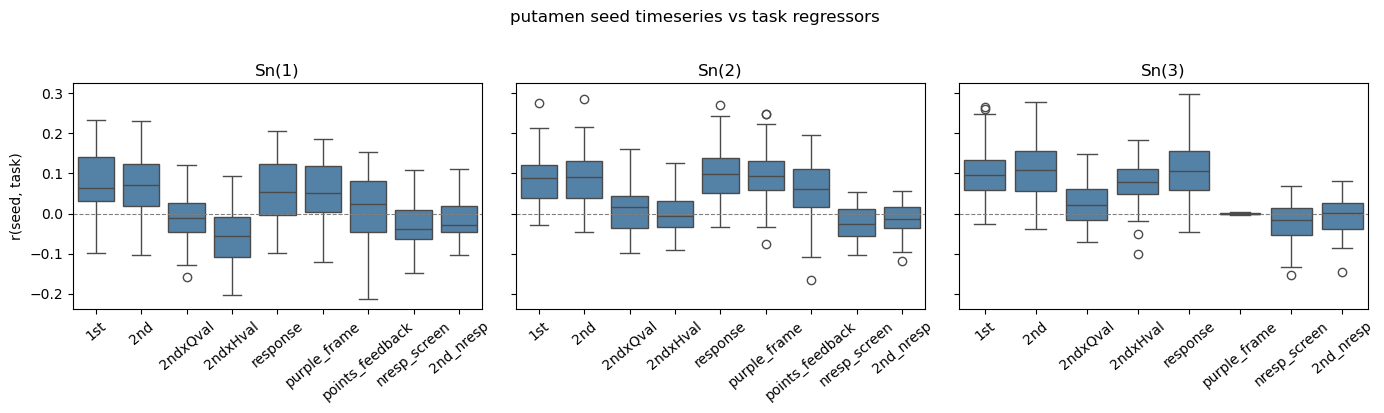

In [12]:
def compute_seed_task_corr(DMs, seed_name, n_sessions=3):
    records = []
    for sub, dm in DMs.items():
        for sn in range(1, n_sessions + 1):
            prefix = f'Sn({sn}) '
            seed_col = f'{prefix}{seed_name}_seedtc'
            if seed_col not in dm.columns:
                continue
            task_cols = [
                c for c in dm.columns
                if c.startswith(prefix)
                and not re.search(r'\bR\d+$', c)
                and 'constant' not in c.lower()
                and 'PPI_' not in c
                and seed_name not in c
                and dm[c].nunique() > 1
            ]
            for tc in task_cols:
                r = dm[seed_col].corr(dm[tc])
                records.append({
                    'subject': sub,
                    'session': f'Sn({sn})',
                    'regressor': shorten(tc.replace(prefix, '')),
                    'r': r,
                })
    return pd.DataFrame(records)


seed_corr_df = compute_seed_task_corr(DMs, SEED_NAME)

print('=== r(seed_tc, task regressor) — mean (std) across subjects ===')
display(seed_corr_df.groupby(['regressor', 'session'])['r'].agg(['mean', 'std']).round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, sn in zip(axes, ['Sn(1)', 'Sn(2)', 'Sn(3)']):
    subset = seed_corr_df[seed_corr_df['session'] == sn]
    sns.boxplot(data=subset, x='regressor', y='r', color='steelblue', ax=ax)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(sn)
    ax.set_xlabel('')
    ax.set_ylabel('r(seed, task)' if ax is axes[0] else '')
    ax.tick_params(axis='x', rotation=40)

plt.suptitle(f'{SEED_NAME} seed timeseries vs task regressors', y=1.02)
plt.tight_layout()
plt.show()

## Correlation: PPI pmod regressors vs PPI_second_stim

As argued above, the elevated VIF for `PPI_second_stimxHval_chosen` in Sn(1) is likely driven not by collinearity with its base task regressor, but by near-proportionality with `PPI_second_stim` — because a near-flat Hval pmod makes the interaction term approximately a scaled copy of the main condition PPI. This cell tests that directly.

=== r(PPI_pmod, PPI_second_stim) — mean (std) across subjects ===


mean    std
regressor session              
2ndxHval  Sn(1)   -0.946  0.020
          Sn(2)   -0.098  0.193
          Sn(3)    0.620  0.104
2ndxQval  Sn(1)   -0.242  0.202
          Sn(2)    0.008  0.152
          Sn(3)    0.045  0.169

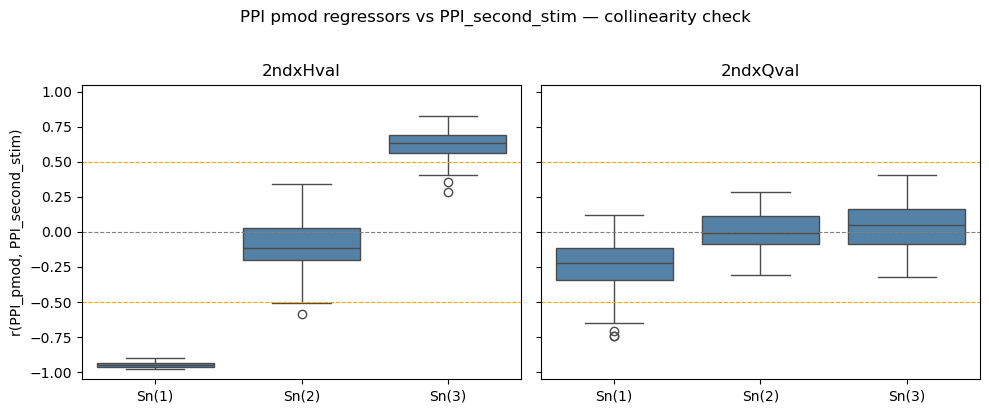

In [18]:
def compute_ppi_pmod_vs_ppi_second_stim(DMs, seed_name, n_sessions=3):
    """
    For each PPI pmod interaction regressor (those containing 'x' in the name),
    correlate with PPI_second_stim within the same session.
    """
    records = []
    for sub, dm in DMs.items():
        for sn in range(1, n_sessions + 1):
            prefix = f'Sn({sn}) '
            ref_col = f'{prefix}PPI_second_stim'
            if ref_col not in dm.columns:
                continue
            pmod_cols = [
                c for c in dm.columns
                if c.startswith(prefix + 'PPI_')
                and 'x' in c.replace(prefix + 'PPI_', '')
                and seed_name not in c
            ]
            for pc in pmod_cols:
                cond = pc.replace(prefix + 'PPI_', '')
                r = dm[pc].corr(dm[ref_col])
                records.append({
                    'subject': sub,
                    'session': f'Sn({sn})',
                    'regressor': shorten(cond),
                    'r': r,
                })
    return pd.DataFrame(records)


ppi_pmod_corr_df = compute_ppi_pmod_vs_ppi_second_stim(DMs, SEED_NAME)

print('=== r(PPI_pmod, PPI_second_stim) — mean (std) across subjects ===')
display(ppi_pmod_corr_df.groupby(['regressor', 'session'])['r'].agg(['mean', 'std']).round(3))

regressors = sorted(ppi_pmod_corr_df['regressor'].unique())
n = len(regressors)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)
if n == 1:
    axes = [axes]

for ax, reg in zip(axes, regressors):
    subset = ppi_pmod_corr_df[ppi_pmod_corr_df['regressor'] == reg]
    sns.boxplot(data=subset, x='session', y='r', color='steelblue', ax=ax)
    ax.axhline(0,    color='gray',   linestyle='--', linewidth=0.8)
    ax.axhline( 0.5, color='orange', linestyle='--', linewidth=0.8)
    ax.axhline(-0.5, color='orange', linestyle='--', linewidth=0.8)
    ax.set_title(reg)
    ax.set_xlabel('')
    ax.set_ylabel('r(PPI_pmod, PPI_second_stim)' if ax is axes[0] else '')
    ax.set_ylim(-1.05, 1.05)

plt.suptitle('PPI pmod regressors vs PPI_second_stim — collinearity check', y=1.02)
plt.tight_layout()
plt.show()